In [3]:
# ============================
# Import required libraries
# ============================

import ast                          # Convert string representations of lists into real Python lists
import pandas as pd                 # Data manipulation and analysis
from datasets import load_dataset   # Load the sample jobs dataset
import matplotlib.pyplot as plt     # Create and format charts

# ============================
# Load the dataset
# ============================

dataset = load_dataset('lukebarousse/data_jobs')   # Download the jobs dataset
df = dataset['train'].to_pandas()                  # Convert it into a pandas DataFrame

# ============================
# Clean the data
# ============================

# Convert the posting date from text into a datetime object
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

# Convert job_skills from string format into actual Python lists
# Skip missing values (NaN)
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

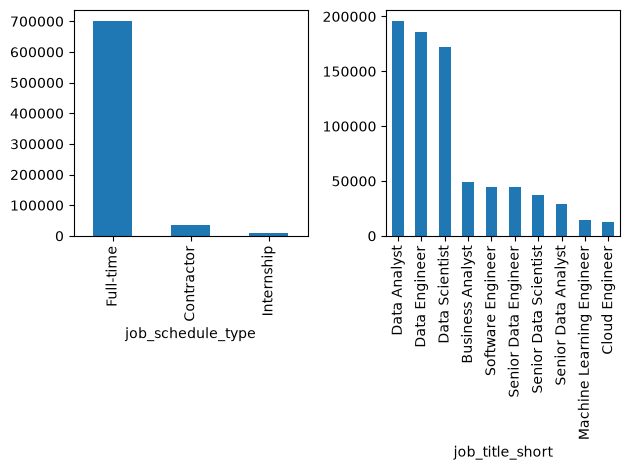

In [7]:
# Create a figure with 1 row and 2 columns of subplots
fig, ax = plt.subplots(1, 2)

# Plot ALL job titles on the second subplot (ax[1])
df['job_title_short'].value_counts().plot(
    kind='bar',          # Vertical bar chart
    ax=ax[1]             # Draw on the second subplot
)

# Plot only the TOP 3 job schedule types on the first subplot (ax[0])
df['job_schedule_type'].value_counts().head(3).plot(
    kind='bar',          # Vertical bar chart
    ax=ax[0]             # Draw on the first subplot
)

# Automatically adjust spacing between the two charts
fig.tight_layout()

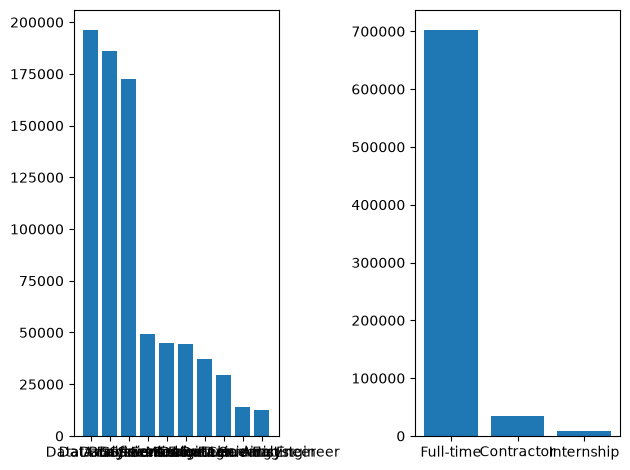

In [8]:
# Create a figure with 1 row and 2 columns
fig, ax = plt.subplots(1, 2)

# Draw a bar chart manually on the first subplot
ax[0].bar(
    df['job_title_short'].value_counts().index,   # x-axis labels
    df['job_title_short'].value_counts()          # bar heights
)

# Draw another bar chart manually on the second subplot
ax[1].bar(
    df['job_schedule_type'].value_counts().head(3).index,   # x-axis labels
    df['job_schedule_type'].value_counts().head(3)          # top 3 counts
)

# Automatically adjust spacing
plt.tight_layout()

In [9]:
# Make a copy so the original DataFrame stays unchanged
df_skills = df.copy()

# Split each list of skills into separate rows
df_skills = df_skills.explode('job_skills')

# Count each (skill, job title) combination
skills_count = df_skills.groupby(
    ['job_skills', 'job_title_short']
).size()

# Convert the Series into a DataFrame and name the count column
df_skills_count = skills_count.reset_index(name='skill_count')

# Sort from the most common skills to the least common
df_skills_count.sort_values(
    by='skill_count',
    ascending=False,
    inplace=True
)

# Display the result
df_skills_count

,job_skills,job_title_short,skill_count
1480,python,Data Scientist,113711
1822,sql,Data Engineer,113130
1479,python,Data Engineer,108022
1821,sql,Data Analyst,92428
1823,sql,Data Scientist,78982
...,...,...,...
2173,webex,Senior Data Scientist,1
1054,mattermost,Data Scientist,1
270,clickup,Machine Learning Engineer,1
797,heroku,Senior Data Analyst,1


In [11]:
job_titles= ['Data Scientist', 'Data Analyst', 'Data Engineer']

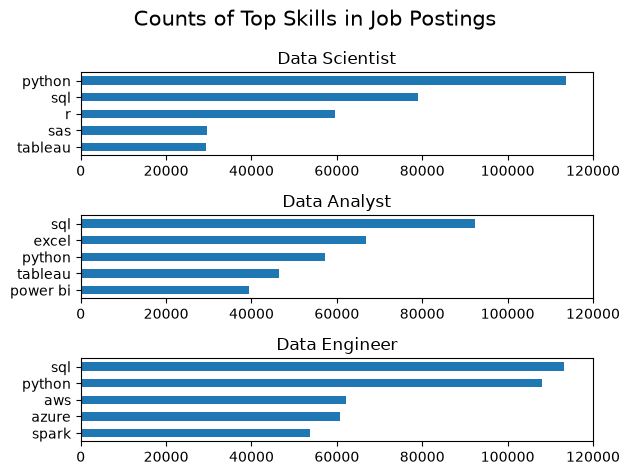

In [ ]:
# Create a figure with 3 rows and 1 column of subplots
fig, ax = plt.subplots(3, 1)

# enumerate() gives:
# i = subplot index (0, 1, 2)
# job_title = current job title from the list
for i, job_title in enumerate(job_titles):

    # Filter for one job title and keep only the top 5 skills
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)

    # Plot a horizontal bar chart on subplot i
    df_plot.plot(
        kind='barh',          # Horizontal bar chart
        x='job_skills',       # Skill names on the y-axis
        y='skill_count',      # Bar length = number of job postings
        ax=ax[i],             # Draw on subplot i (0, 1, or 2)
        title=job_title       # Use the job title as the chart title
    )

    ax[i].invert_yaxis()          # Put the highest-ranked skill at the top
    ax[i].set_ylabel('')          # Remove the default y-axis label
    ax[i].legend().set_visible(False)  # Hide the legend (it's redundant)
    ax[i].set_xlim(0, 120000)  # Make all charts the same width

# Automatically adjust spacing between all subplots

fig.suptitle('Counts of Top Skills in Job Postings', fontsize=15) # Add a title for the entire figure (all subplots)
fig.tight_layout()
